In [1]:
from google.colab import drive
drive.mount('/content/drive')
import sys, pickle
ROOT = '/content/drive/MyDrive/CW_Folder_UG'
sys.path.insert(0, f'{ROOT}/Code')
from utils import *
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

MODELS_DIR = f'{ROOT}/Models'
os.makedirs(MODELS_DIR, exist_ok=True)

with open(f'{ROOT}/Code/data_splits.pkl', 'rb') as f:
    d = pickle.load(f)
train_paths, train_labels = d['train_paths'], d['train_labels']
test_paths,  test_labels  = d['test_paths'],  d['test_labels']
y_test = np.array(test_labels)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Mounted at /content/drive
Device: cuda


In [2]:
import shutil, os

LOCAL_ROOT = '/tmp/CW_data'

if not os.path.exists(LOCAL_ROOT):
    print("Copying dataset to local SSD.")
    shutil.copytree(ROOT, LOCAL_ROOT)
    print("Done.")
else:
    print("Local copy already exists, skipping.")

# Remap paths from Drive to local SSD
def remap(paths, src=ROOT, dst=LOCAL_ROOT):
    return [p.replace(src, dst) for p in paths]

train_paths = remap(train_paths)
test_paths  = remap(test_paths)
print(f"Paths remapped to {LOCAL_ROOT}")

Copying dataset to local SSD.
Done.
Paths remapped to /tmp/CW_data


In [3]:
tr_idx, val_idx = train_test_split(range(len(train_paths)), test_size=0.1,
                                   stratify=train_labels, random_state=SEED)
tr_p   = [train_paths[i] for i in tr_idx]; tr_l  = [train_labels[i] for i in tr_idx]
val_p  = [train_paths[i] for i in val_idx]; val_l = [train_labels[i] for i in val_idx]

cw_tensor = torch.tensor(
    [get_class_weights(tr_l)[i] for i in range(4)], dtype=torch.float
).to(device)

def make_loaders(augment=False, size=IMAGE_SIZE, bs=64):
    tr_ds  = AgeDataset(tr_p,  tr_l,  get_transforms(size, augment=augment))
    val_ds = AgeDataset(val_p, val_l, get_transforms(size))
    te_ds  = AgeDataset(test_paths, test_labels, get_transforms(size))
    kw = dict(num_workers=2, pin_memory=True)
    return (DataLoader(tr_ds,  bs, shuffle=True,  **kw),
            DataLoader(val_ds, bs, shuffle=False, **kw),
            DataLoader(te_ds,  bs, shuffle=False, **kw))

print(f'Train: {len(tr_p)}  Val: {len(val_p)}  Test: {len(test_paths)}')

Train: 11970  Val: 1330  Test: 850


In [4]:
def conv_block(in_ch, out_ch, dropout=0.25):
    """Two Conv2d layers with BN, ReLU, MaxPool and spatial Dropout."""
    return nn.Sequential(
        nn.Conv2d(in_ch,  out_ch, kernel_size=3, padding=1),
        nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
        nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        nn.MaxPool2d(2, 2),
        nn.Dropout2d(dropout)
    )


class ShallowCNN(nn.Module):
    """2 conv blocks + FC head (Track 3a)."""
    def __init__(self, nc=4):
        super().__init__()
        self.features = nn.Sequential(
            conv_block(3,  32),  # 128→64
            conv_block(32, 64),  # 64→32
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 32 * 32, 256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, nc)
        )
    def forward(self, x): return self.head(self.features(x))

class DeeperCNN(nn.Module):
    """4 conv blocks + FC head (Track 3b & 3c)."""
    def __init__(self, nc=4):
        super().__init__()
        self.features = nn.Sequential(
            conv_block(3,   32),   # 128→64
            conv_block(32,  64),   # 64→32
            conv_block(64,  128),  # 32→16
            conv_block(128, 256),  # 16→8
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 8 * 8, 512), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(512, nc)
        )
    def forward(self, x): return self.head(self.features(x))

def count_params(m):
    return sum(p.numel() for p in m.parameters())

print(f'ShallowCNN params: {count_params(ShallowCNN()):,}')
print(f'DeeperCNN  params: {count_params(DeeperCNN()):,}')

ShallowCNN params: 16,844,452
DeeperCNN  params: 9,565,348


In [5]:
def run_track3(name, model, augment=False, lr=1e-3, epochs=30):
    save_path = f'{MODELS_DIR}/track3_{name}.pt'
    tr_dl, val_dl, te_dl = make_loaders(augment=augment)
    criterion = nn.CrossEntropyLoss(weight=cw_tensor)
    opt   = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    print(f'Training: {name}')
    t0 = time.time()
    history = train_model(model, tr_dl, val_dl, criterion, opt,
                          sched, epochs, device, save_path)
    tt = time.time() - t0
    val_acc = max(history['val_acc'])
    model.load_state_dict(torch.load(save_path))
    _, preds = eval_epoch(model, te_dl, device)
    test_acc = accuracy_score(y_test, preds)
    plot_history(history, title=name)
    return {'val_acc': val_acc, 'test_acc': test_acc, 'train_time': tt,
            'test_preds': preds, 'path': save_path}

Training: ShallowCNN_2conv
  Ep   5/30  loss=0.9861  val_acc=0.5759  best=0.5977
  Ep  10/30  loss=0.8338  val_acc=0.7083  best=0.7241
  Ep  15/30  loss=0.7521  val_acc=0.7226  best=0.7256
  Ep  20/30  loss=0.6900  val_acc=0.7301  best=0.7429
  Ep  25/30  loss=0.6524  val_acc=0.7496  best=0.7511
  Ep  30/30  loss=0.6172  val_acc=0.7534  best=0.7564

  Best val acc: 0.7564  ->  /content/drive/MyDrive/CW_Folder_UG/Models/track3_ShallowCNN_2conv.pt


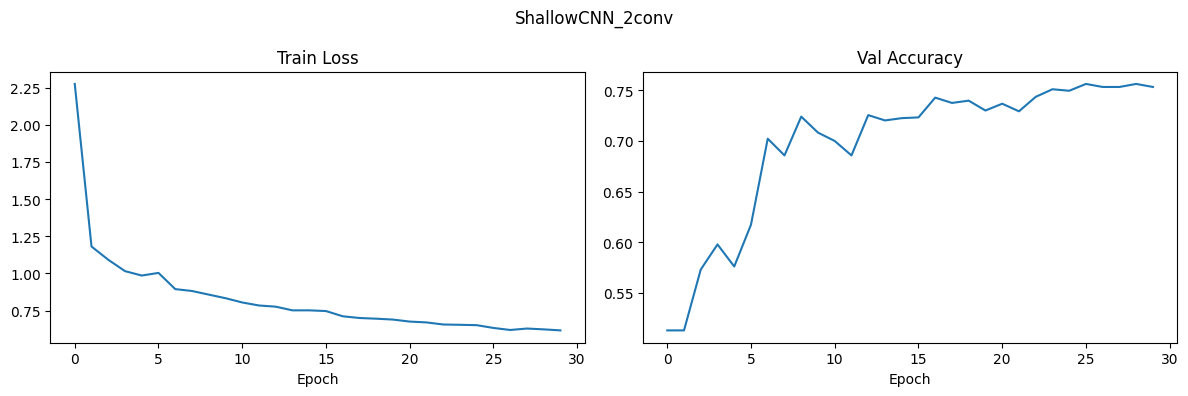

In [6]:
res_3a = run_track3('ShallowCNN_2conv', ShallowCNN().to(device), augment=False)

Training: DeeperCNN_4conv
  Ep   5/30  loss=0.9011  val_acc=0.6647  best=0.6647
  Ep  10/30  loss=0.7415  val_acc=0.7128  best=0.7128
  Ep  15/30  loss=0.6627  val_acc=0.7248  best=0.7248
  Ep  20/30  loss=0.5642  val_acc=0.7323  best=0.7406
  Ep  25/30  loss=0.4864  val_acc=0.7474  best=0.7579
  Ep  30/30  loss=0.4474  val_acc=0.7549  best=0.7579

  Best val acc: 0.7579  ->  /content/drive/MyDrive/CW_Folder_UG/Models/track3_DeeperCNN_4conv.pt


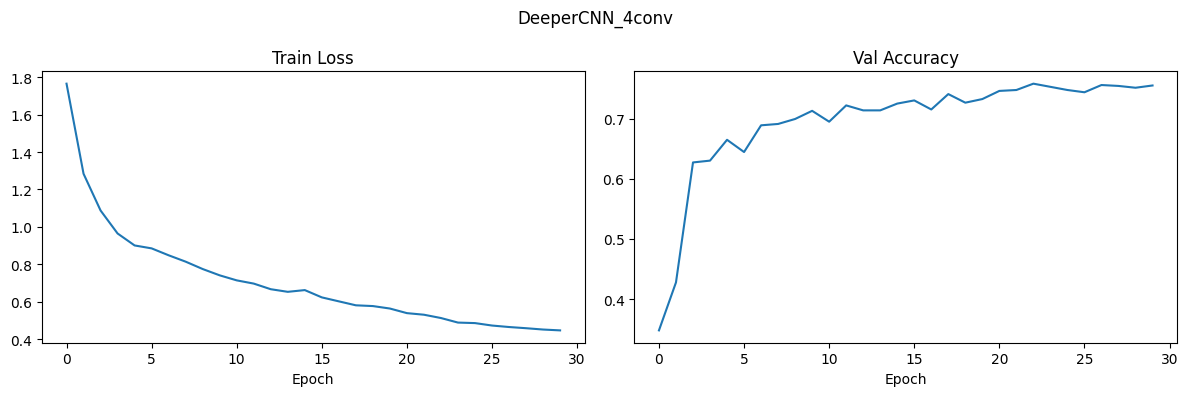

In [7]:
res_3b = run_track3('DeeperCNN_4conv', DeeperCNN().to(device), augment=False)

Training: DeeperCNN_4conv_aug
  Ep   5/30  loss=1.0334  val_acc=0.6023  best=0.6489
  Ep  10/30  loss=0.8629  val_acc=0.7143  best=0.7143
  Ep  15/30  loss=0.7735  val_acc=0.7519  best=0.7519
  Ep  20/30  loss=0.7286  val_acc=0.7571  best=0.7571
  Ep  25/30  loss=0.6866  val_acc=0.7669  best=0.7669
  Ep  30/30  loss=0.6729  val_acc=0.7602  best=0.7669

  Best val acc: 0.7669  ->  /content/drive/MyDrive/CW_Folder_UG/Models/track3_DeeperCNN_4conv_aug.pt


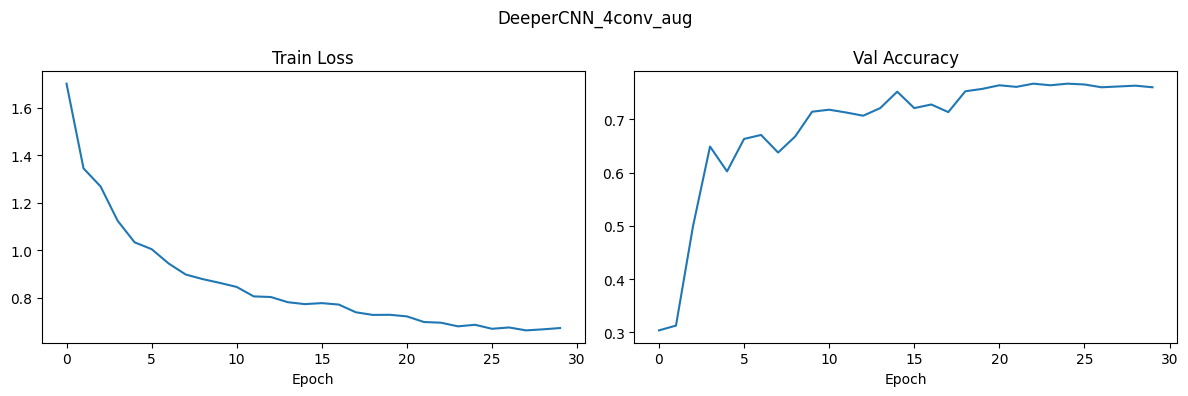

In [8]:
res_3c = run_track3('DeeperCNN_4conv_aug', DeeperCNN().to(device), augment=True)

In [9]:
results = {
    'ShallowCNN_2conv':    res_3a,
    'DeeperCNN_4conv':     res_3b,
    'DeeperCNN_4conv_aug': res_3c,
}
print(f"{'Model':<25} {'Val Acc':>9} {'Test Acc':>10} {'Time(s)':>9}")
print('─' * 57)
for n, r in sorted(results.items(), key=lambda x: -x[1]['test_acc']):
    print(f"{n:<25} {r['val_acc']:>9.4f} {r['test_acc']:>10.4f} {r['train_time']:>9.1f}")

best_name = max(results, key=lambda n: results[n]['test_acc'])
print(f"Best Track 3: {best_name}  (test acc={results[best_name]['test_acc']:.4f})")

Model                       Val Acc   Test Acc   Time(s)
─────────────────────────────────────────────────────────
DeeperCNN_4conv              0.7579     0.7871     108.6
DeeperCNN_4conv_aug          0.7669     0.7859     170.1
ShallowCNN_2conv             0.7564     0.7824     102.9

Best Track 3: DeeperCNN_4conv  (test acc=0.7871)


In [10]:
for name, r in results.items():
    evaluate(name, y_test, r['test_preds'], r['train_time'], r['path'])

Model: ShallowCNN_2conv
Training Time: 102.9 seconds
Model Size: 64.27 MB
Accuracy: 0.7824
Classification Report:
              precision    recall  f1-score   support

       Child       0.91      0.92      0.92       150
       Young       0.86      0.82      0.84       350
 Middle-Aged       0.60      0.62      0.61       200
      Senior       0.73      0.77      0.75       150

    accuracy                           0.78       850
   macro avg       0.78      0.78      0.78       850
weighted avg       0.79      0.78      0.78       850

Model: DeeperCNN_4conv
Training Time: 108.6 seconds
Model Size: 36.52 MB
Accuracy: 0.7871
Classification Report:
              precision    recall  f1-score   support

       Child       0.88      0.94      0.91       150
       Young       0.87      0.86      0.86       350
 Middle-Aged       0.63      0.58      0.61       200
      Senior       0.70      0.73      0.71       150

    accuracy                           0.79       850
   macro avg

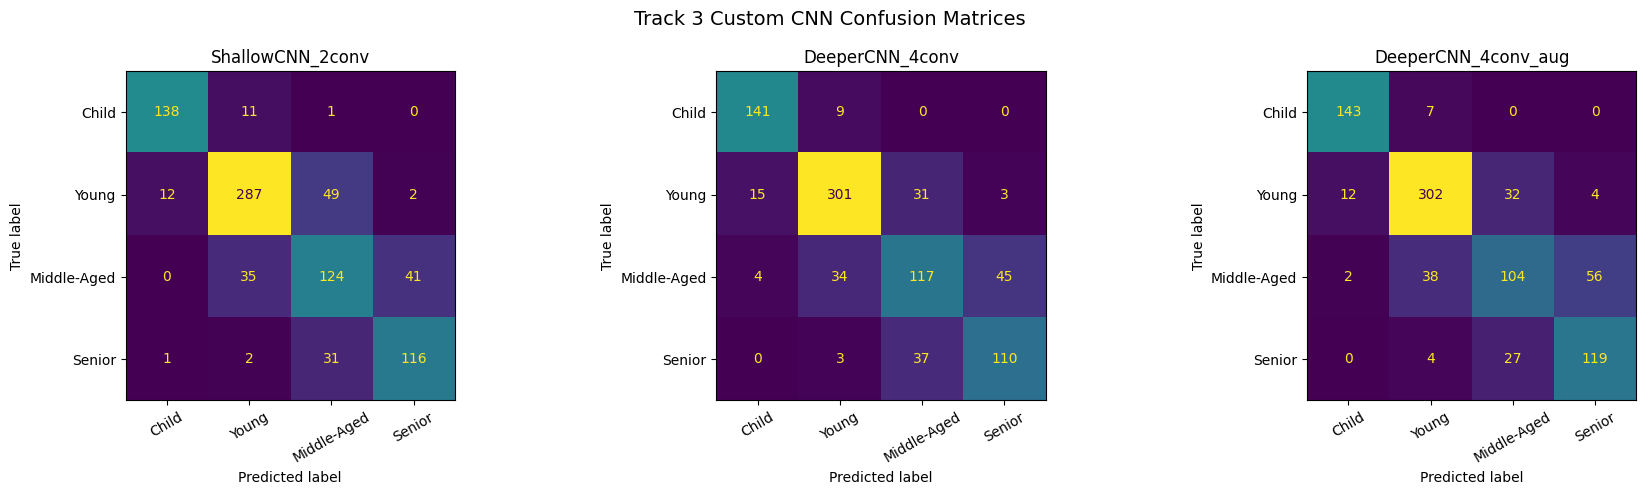

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (n, r) in zip(axes, results.items()):
    plot_confusion_matrix(n, y_test, r['test_preds'], ax=ax)
plt.suptitle('Track 3 Custom CNN Confusion Matrices', fontsize=14)
plt.tight_layout()
plt.show()

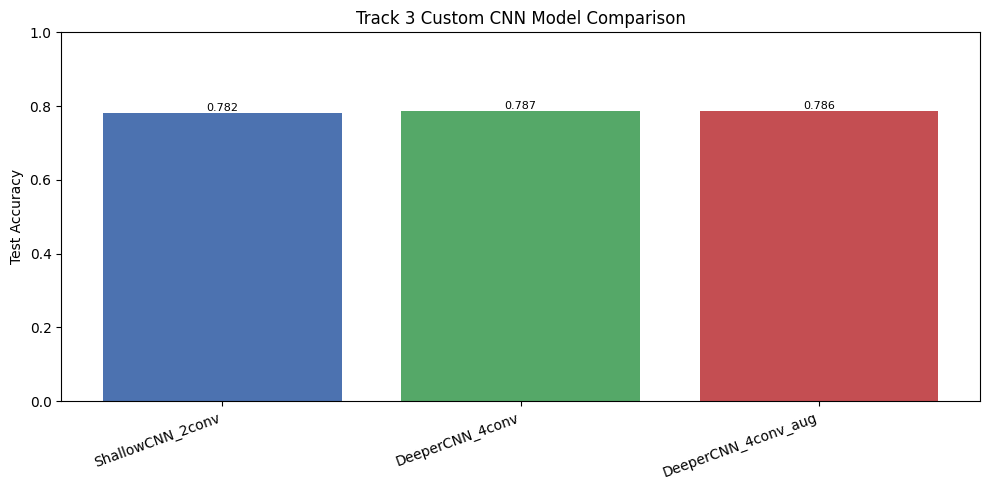

In [16]:
names  = list(results.keys())
accs   = [results[n]['test_acc'] for n in names]
colors = ['#4C72B0', '#55A868', '#C44E52']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(names, accs, color=colors)
ax.set_ylim(0, 1); ax.set_ylabel('Test Accuracy')
ax.set_title('Track 3 Custom CNN Model Comparison')
plt.xticks(rotation=20, ha='right')
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005, f'{acc:.3f}',
            ha='center', fontsize=8)
plt.tight_layout()
plt.show()

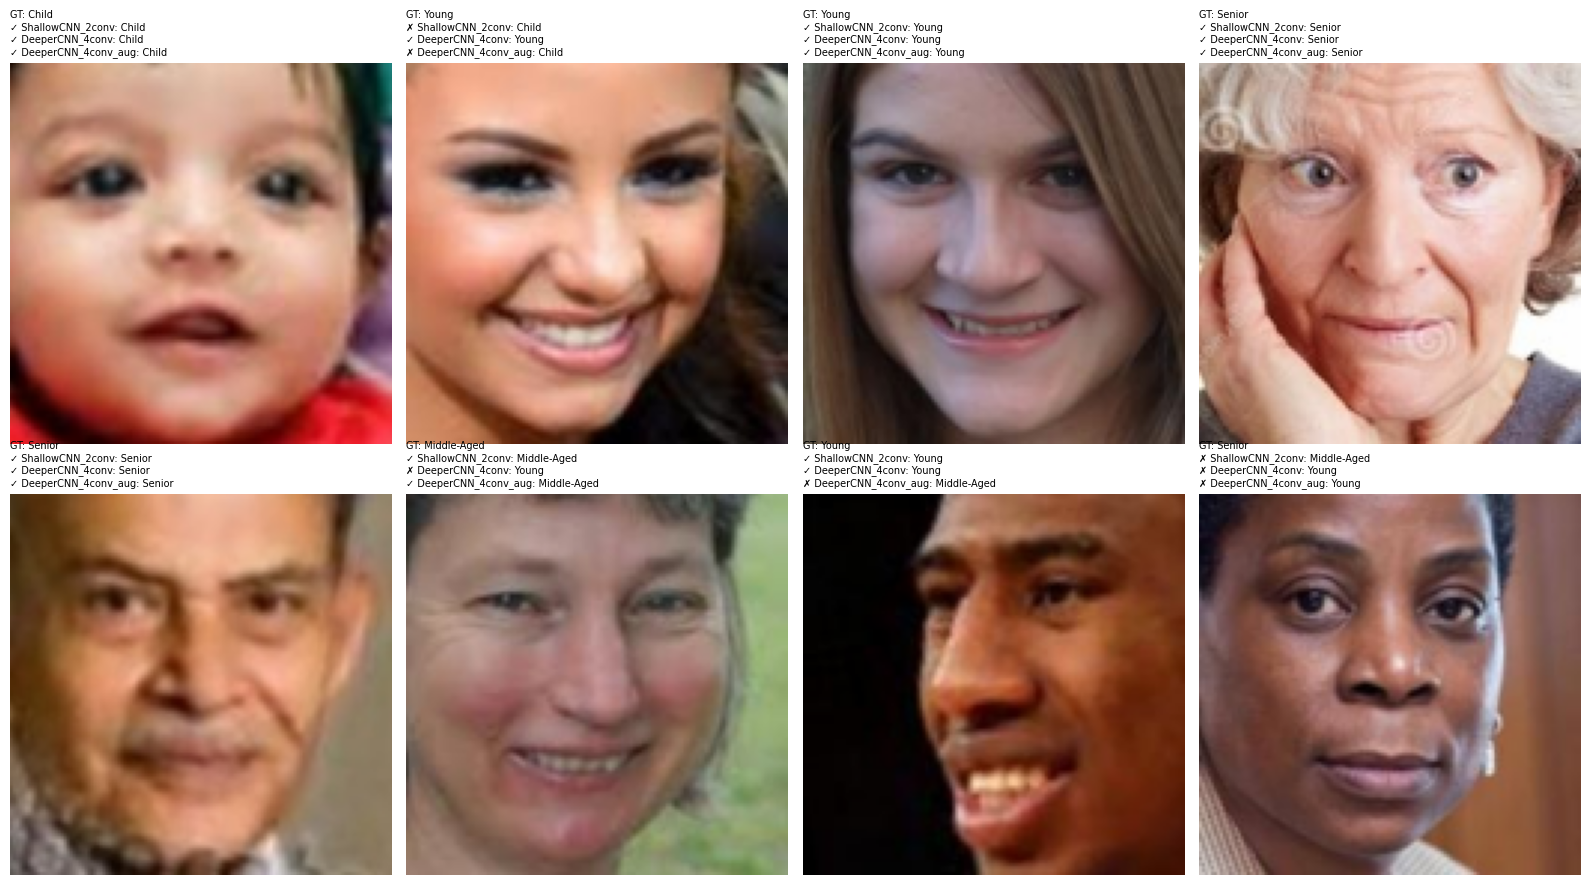

In [13]:
qualitative_grid(test_paths, test_labels,
                 {n: r['test_preds'] for n, r in results.items()}, n=8)

In [14]:
with open(f'{ROOT}/Code/track3_results.pkl', 'wb') as f:
    pickle.dump({'results': results, 'best_name': best_name}, f)
print('Track 3 results saved')

Track 3 results saved
